In [6]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import json
import pickle
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

KAGGLE_BASE_PATH = '/kaggle/input/my-cefr-models'

print("="*80)
print("CEFR CLASSIFICATION MODELS - COMPREHENSIVE COMPARISON")
print("="*80)
print("\nComparing 4 Models:")
print("  1. DistilBERT (Transformer Fine-tuning)")
print("  2. ELECTRA (Transformer Fine-tuning)")
print("  3. LSTM with Attention (Custom Architecture)")
print("  4. CNN with Global Pooling (Custom Architecture)")
print("="*80)

CEFR CLASSIFICATION MODELS - COMPREHENSIVE COMPARISON

Comparing 4 Models:
  1. DistilBERT (Transformer Fine-tuning)
  2. ELECTRA (Transformer Fine-tuning)
  3. LSTM with Attention (Custom Architecture)
  4. CNN with Global Pooling (Custom Architecture)


In [8]:
# Setup and Configuration
print("\n" + "="*80)
print("SETTING UP ENVIRONMENT")
print("="*80)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nDevice: {device}")

# Load preprocessed data
print("\nLoading preprocessed data...")
X_test = np.load('/kaggle/input/datasets/ahmedsameh72/my-cefr-models/running/X_test.npy', allow_pickle=True)
y_test = np.load('/kaggle/input/datasets/ahmedsameh72/my-cefr-models/running/y_test.npy', allow_pickle=True)

with open('/kaggle/input/datasets/ahmedsameh72/my-cefr-models/running/label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)

print(f"Test set size: {len(X_test)}")
print(f"Number of classes: {len(label_encoder.classes_)}")
print(f"Classes: {label_encoder.classes_}")
print("="*80)


SETTING UP ENVIRONMENT

Device: cuda

Loading preprocessed data...
Test set size: 22520
Number of classes: 6
Classes: ['A1' 'A2' 'B1' 'B2' 'C1' 'C2']


In [9]:
# Define Custom Model Classes
print("\nDefining custom model architectures...")

# Simple Tokenizer
class SimpleTokenizer:
    def __init__(self, vocab_size=10000, max_length=512):
        self.vocab_size = vocab_size
        self.max_length = max_length
        self.word2idx = {'<PAD>': 0, '<UNK>': 1}
        self.idx2word = {0: '<PAD>', 1: '<UNK>'}
        self.current_idx = 2

    def build_vocab(self, texts):
        word_freq = {}
        for text in texts:
            words = text.lower().split()
            for word in words:
                word_freq[word] = word_freq.get(word, 0) + 1

        sorted_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)
        for word, freq in sorted_words:
            if len(self.word2idx) < self.vocab_size:
                self.word2idx[word] = self.current_idx
                self.idx2word[self.current_idx] = word
                self.current_idx += 1

    def encode(self, text):
        words = text.lower().split()
        indices = []
        for word in words:
            if word in self.word2idx:
                indices.append(self.word2idx[word])
            else:
                indices.append(self.word2idx['<UNK>'])

        if len(indices) < self.max_length:
            indices = indices + [0] * (self.max_length - len(indices))
        else:
            indices = indices[:self.max_length]

        return indices

# LSTM with Attention Model
class CEFRModel1(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, lstm_hidden=256, num_classes=6, dropout=0.3):
        super(CEFRModel1, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, lstm_hidden, batch_first=True,
                            bidirectional=True, dropout=dropout if dropout > 0 else 0)

        self.attention = nn.Linear(lstm_hidden * 2, 1)
        self.softmax = nn.Softmax(dim=1)

        self.fc1 = nn.Linear(lstm_hidden * 2, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, num_classes)

        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

    def forward(self, input_ids):
        x = self.embedding(input_ids)
        x = self.dropout(x)

        lstm_out, _ = self.lstm(x)

        attention_weights = self.attention(lstm_out)
        attention_weights = self.softmax(attention_weights)
        context = (lstm_out * attention_weights).sum(dim=1)

        x = self.relu(self.fc1(context))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        logits = self.fc3(x)

        return logits

# CNN Model
class CEFRModel2(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, num_filters=100, num_classes=6, dropout=0.3):
        super(CEFRModel2, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        self.conv1 = nn.Conv1d(embedding_dim, num_filters, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(embedding_dim, num_filters, kernel_size=4, padding=1)
        self.conv3 = nn.Conv1d(embedding_dim, num_filters, kernel_size=5, padding=2)

        self.fc1 = nn.Linear(num_filters * 3, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, num_classes)

        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

    def forward(self, input_ids):
        x = self.embedding(input_ids)
        x = self.dropout(x)
        x = x.permute(0, 2, 1)

        conv1_out = self.relu(self.conv1(x))
        conv2_out = self.relu(self.conv2(x))
        conv3_out = self.relu(self.conv3(x))

        pool1 = torch.mean(conv1_out, dim=2)
        pool2 = torch.mean(conv2_out, dim=2)
        pool3 = torch.mean(conv3_out, dim=2)

        x = torch.cat([pool1, pool2, pool3], dim=1)

        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        logits = self.fc3(x)

        return logits

print("Model classes defined!")


Defining custom model architectures...
Model classes defined!


In [10]:
# Load Transformer Models (DistilBERT and ELECTRA)
print("\n" + "="*80)
print("LOADING TRANSFORMER MODELS")
print("="*80)

from transformers import AutoTokenizer, AutoModelForSequenceClassification

# DistilBERT
print("\nLoading DistilBERT...")
try:
    distilbert_tokenizer = AutoTokenizer.from_pretrained('/kaggle/input/datasets/ahmedsameh72/my-cefr-models/models/distilbert_cefr_classifier')
    distilbert_model = AutoModelForSequenceClassification.from_pretrained('/kaggle/input/datasets/ahmedsameh72/my-cefr-models/models/distilbert_cefr_classifier').to(device)
    distilbert_model.eval()
    print("DistilBERT loaded successfully")
except Exception as e:
    print(f"Error loading DistilBERT: {e}")
    distilbert_model = None

# ELECTRA
print("\nLoading ELECTRA...")
try:
    electra_tokenizer = AutoTokenizer.from_pretrained('/kaggle/input/datasets/ahmedsameh72/my-cefr-models/models/electra_cefr_classifier')
    electra_model = AutoModelForSequenceClassification.from_pretrained('/kaggle/input/datasets/ahmedsameh72/my-cefr-models/models/electra_cefr_classifier').to(device)
    electra_model.eval()
    print("ELECTRA loaded successfully")
except Exception as e:
    print(f"Error loading ELECTRA: {e}")
    electra_model = None

print("="*80)


LOADING TRANSFORMER MODELS

Loading DistilBERT...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBERT loaded successfully

Loading ELECTRA...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

ELECTRA loaded successfully


In [11]:
# Load Custom Models (LSTM and CNN)
print("\n" + "="*80)
print("LOADING CUSTOM MODELS")
print("="*80)

# LSTM with Attention
print("\nLoading LSTM with Attention...")
try:
    with open('/kaggle/input/datasets/ahmedsameh72/my-cefr-models/models/LSTM_attention_cefr_classifier/config.json', 'r') as f:
        lstm_config = json.load(f)

    lstm_model = CEFRModel1(
        vocab_size=lstm_config['vocab_size'],
        embedding_dim=lstm_config['embedding_dim'],
        lstm_hidden=lstm_config['lstm_hidden'],
        num_classes=lstm_config['num_classes'],
        dropout=lstm_config['dropout']
    ).to(device)

    lstm_model.load_state_dict(torch.load('/kaggle/input/datasets/ahmedsameh72/my-cefr-models/models/LSTM_attention_cefr_classifier/model_weights.pt', map_location=device))
    lstm_model.eval()

    with open('/kaggle/input/datasets/ahmedsameh72/my-cefr-models/models/LSTM_attention_cefr_classifier/tokenizer.pkl', 'rb') as f:
        lstm_tokenizer = pickle.load(f)

    print("LSTM with Attention loaded successfully")
except Exception as e:
    print(f"Error loading LSTM: {e}")
    lstm_model = None

# CNN with Global Pooling
print("\nLoading CNN with Global Pooling...")
try:
    with open('/kaggle/input/datasets/ahmedsameh72/my-cefr-models/models/CNN_cefr_classifier/config.json', 'r') as f:
        cnn_config = json.load(f)

    cnn_model = CEFRModel2(
        vocab_size=cnn_config['vocab_size'],
        embedding_dim=cnn_config['embedding_dim'],
        num_filters=cnn_config['num_filters'],
        num_classes=cnn_config['num_classes'],
        dropout=cnn_config['dropout']
    ).to(device)

    cnn_model.load_state_dict(torch.load('/kaggle/input/datasets/ahmedsameh72/my-cefr-models/models/CNN_cefr_classifier/model_weights.pt', map_location=device))
    cnn_model.eval()

    with open('/kaggle/input/datasets/ahmedsameh72/my-cefr-models/models/CNN_cefr_classifier/tokenizer.pkl', 'rb') as f:
        cnn_tokenizer = pickle.load(f)

    print("CNN with Global Pooling loaded successfully")
except Exception as e:
    print(f"Error loading CNN: {e}")
    cnn_model = None

print("="*80)


LOADING CUSTOM MODELS

Loading LSTM with Attention...
LSTM with Attention loaded successfully

Loading CNN with Global Pooling...
CNN with Global Pooling loaded successfully


In [12]:
# Evaluate All Models
print("\n" + "="*80)
print("EVALUATING ALL MODELS ON TEST SET")
print("="*80)

results = {}

# DistilBERT Evaluation
if distilbert_model is not None:
    print("\n[1/4] Evaluating DistilBERT...")
    distilbert_preds = []
    with torch.no_grad():
        for text in X_test:
            inputs = distilbert_tokenizer(str(text), return_tensors='pt', max_length=512,
                                         padding='max_length', truncation=True).to(device)
            outputs = distilbert_model(**inputs)
            pred = torch.argmax(outputs.logits, dim=1).item()
            distilbert_preds.append(pred)

    distilbert_acc = accuracy_score(y_test, distilbert_preds)
    distilbert_f1_macro = f1_score(y_test, distilbert_preds, average='macro')
    distilbert_f1_weighted = f1_score(y_test, distilbert_preds, average='weighted')

    results['DistilBERT'] = {
        'accuracy': distilbert_acc,
        'f1_macro': distilbert_f1_macro,
        'f1_weighted': distilbert_f1_weighted,
        'predictions': distilbert_preds,
        'type': 'Transformer'
    }
    print(f"✅ Accuracy: {distilbert_acc:.4f}")

# ELECTRA Evaluation
if electra_model is not None:
    print("\n[2/4] Evaluating ELECTRA...")
    electra_preds = []
    with torch.no_grad():
        for text in X_test:
            inputs = electra_tokenizer(str(text), return_tensors='pt', max_length=512,
                                      padding='max_length', truncation=True).to(device)
            outputs = electra_model(**inputs)
            pred = torch.argmax(outputs.logits, dim=1).item()
            electra_preds.append(pred)

    electra_acc = accuracy_score(y_test, electra_preds)
    electra_f1_macro = f1_score(y_test, electra_preds, average='macro')
    electra_f1_weighted = f1_score(y_test, electra_preds, average='weighted')

    results['ELECTRA'] = {
        'accuracy': electra_acc,
        'f1_macro': electra_f1_macro,
        'f1_weighted': electra_f1_weighted,
        'predictions': electra_preds,
        'type': 'Transformer'
    }
    print(f"✅ Accuracy: {electra_acc:.4f}")

# LSTM Evaluation
if lstm_model is not None:
    print("\n[3/4] Evaluating LSTM with Attention...")
    lstm_preds = []
    with torch.no_grad():
        for text in X_test:
            input_ids = lstm_tokenizer.encode(text)
            input_tensor = torch.tensor([input_ids], dtype=torch.long).to(device)
            logits = lstm_model(input_tensor)
            pred = torch.argmax(logits, dim=1).item()
            lstm_preds.append(pred)

    lstm_acc = accuracy_score(y_test, lstm_preds)
    lstm_f1_macro = f1_score(y_test, lstm_preds, average='macro')
    lstm_f1_weighted = f1_score(y_test, lstm_preds, average='weighted')

    results['LSTM'] = {
        'accuracy': lstm_acc,
        'f1_macro': lstm_f1_macro,
        'f1_weighted': lstm_f1_weighted,
        'predictions': lstm_preds,
        'type': 'Custom'
    }
    print(f"✅ Accuracy: {lstm_acc:.4f}")

# CNN Evaluation
if cnn_model is not None:
    print("\n[4/4] Evaluating CNN with Global Pooling...")
    cnn_preds = []
    with torch.no_grad():
        for text in X_test:
            input_ids = cnn_tokenizer.encode(text)
            input_tensor = torch.tensor([input_ids], dtype=torch.long).to(device)
            logits = cnn_model(input_tensor)
            pred = torch.argmax(logits, dim=1).item()
            cnn_preds.append(pred)

    cnn_acc = accuracy_score(y_test, cnn_preds)
    cnn_f1_macro = f1_score(y_test, cnn_preds, average='macro')
    cnn_f1_weighted = f1_score(y_test, cnn_preds, average='weighted')

    results['CNN'] = {
        'accuracy': cnn_acc,
        'f1_macro': cnn_f1_macro,
        'f1_weighted': cnn_f1_weighted,
        'predictions': cnn_preds,
        'type': 'Custom'
    }
    print(f"✅ Accuracy: {cnn_acc:.4f}")

print("\n" + "="*80)
print("✅ ALL MODELS EVALUATED!")
print("="*80)


EVALUATING ALL MODELS ON TEST SET

[1/4] Evaluating DistilBERT...
✅ Accuracy: 0.9615

[2/4] Evaluating ELECTRA...
✅ Accuracy: 0.9608

[3/4] Evaluating LSTM with Attention...
✅ Accuracy: 0.8726

[4/4] Evaluating CNN with Global Pooling...
✅ Accuracy: 0.9251

✅ ALL MODELS EVALUATED!


In [13]:
# Comparison Table
print("\n" + "="*80)
print("MODEL COMPARISON SUMMARY")
print("="*80)

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Type': [results[model]['type'] for model in results.keys()],
    'Accuracy': [results[model]['accuracy'] for model in results.keys()],
    'F1 Macro': [results[model]['f1_macro'] for model in results.keys()],
    'F1 Weighted': [results[model]['f1_weighted'] for model in results.keys()],
})

comparison_df = comparison_df.sort_values('Accuracy', ascending=False)
print("\n" + comparison_df.to_string(index=False))

# Find best model
best_model = comparison_df.iloc[0]
print(f"\n{'='*80}")
print(f"🏆 BEST MODEL: {best_model['Model']}")
print(f"   Type: {best_model['Type']}")
print(f"   Accuracy: {best_model['Accuracy']:.4f}")
print(f"   F1 Macro: {best_model['F1 Macro']:.4f}")
print(f"   F1 Weighted: {best_model['F1 Weighted']:.4f}")
print("="*80)


MODEL COMPARISON SUMMARY

     Model        Type  Accuracy  F1 Macro  F1 Weighted
DistilBERT Transformer  0.961545  0.895498     0.961602
   ELECTRA Transformer  0.960790  0.901699     0.960807
       CNN      Custom  0.925089  0.809574     0.925520
      LSTM      Custom  0.872602  0.758752     0.875224

🏆 BEST MODEL: DistilBERT
   Type: Transformer
   Accuracy: 0.9615
   F1 Macro: 0.8955
   F1 Weighted: 0.9616


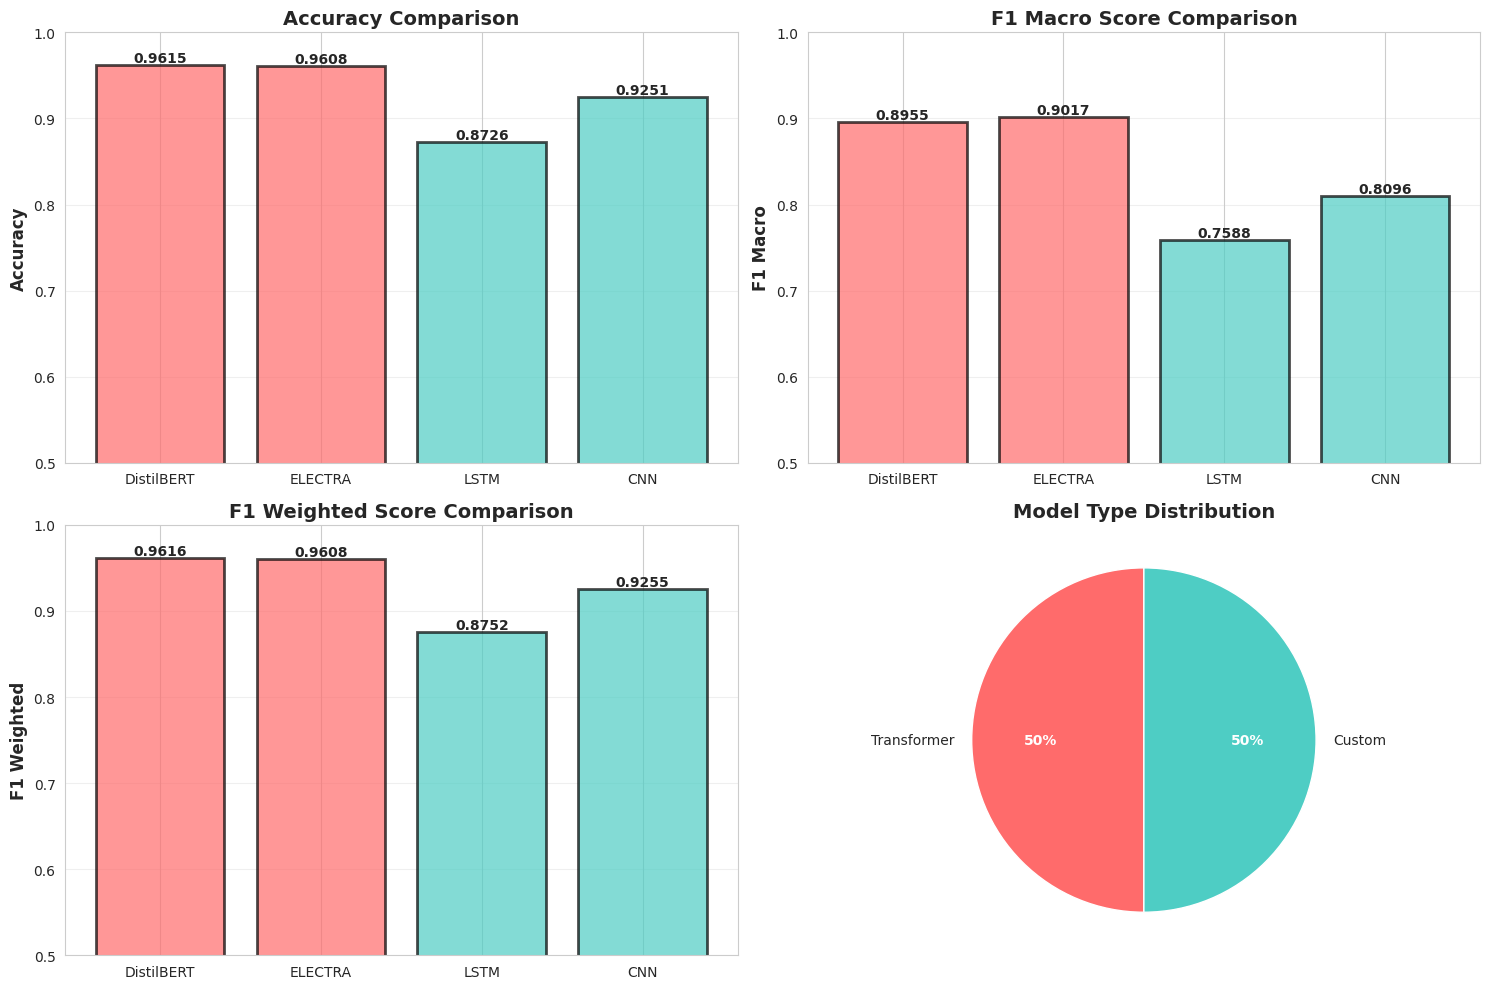


✅ Visualization saved as 'model_comparison_metrics.png'


In [14]:
# Visualization 1: Accuracy Comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Accuracy
ax = axes[0, 0]
models = list(results.keys())
accuracies = [results[m]['accuracy'] for m in models]
colors = ['#FF6B6B' if results[m]['type'] == 'Transformer' else '#4ECDC4' for m in models]
bars = ax.bar(models, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_ylim([0.5, 1.0])
ax.grid(axis='y', alpha=0.3)
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{accuracies[i]:.4f}', ha='center', va='bottom', fontweight='bold')

# F1 Macro
ax = axes[0, 1]
f1_macros = [results[m]['f1_macro'] for m in models]
bars = ax.bar(models, f1_macros, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('F1 Macro', fontsize=12, fontweight='bold')
ax.set_title('F1 Macro Score Comparison', fontsize=14, fontweight='bold')
ax.set_ylim([0.5, 1.0])
ax.grid(axis='y', alpha=0.3)
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{f1_macros[i]:.4f}', ha='center', va='bottom', fontweight='bold')

# F1 Weighted
ax = axes[1, 0]
f1_weighted = [results[m]['f1_weighted'] for m in models]
bars = ax.bar(models, f1_weighted, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('F1 Weighted', fontsize=12, fontweight='bold')
ax.set_title('F1 Weighted Score Comparison', fontsize=14, fontweight='bold')
ax.set_ylim([0.5, 1.0])
ax.grid(axis='y', alpha=0.3)
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{f1_weighted[i]:.4f}', ha='center', va='bottom', fontweight='bold')

# Model Type
ax = axes[1, 1]
model_types = {}
for model in models:
    mtype = results[model]['type']
    if mtype not in model_types:
        model_types[mtype] = 0
    model_types[mtype] += 1

types = list(model_types.keys())
counts = list(model_types.values())
pie_colors = ['#FF6B6B', '#4ECDC4']
wedges, texts, autotexts = ax.pie(counts, labels=types, autopct='%1.0f%%',
                                    colors=pie_colors, startangle=90)
ax.set_title('Model Type Distribution', fontsize=14, fontweight='bold')
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.savefig('model_comparison_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Visualization saved as 'model_comparison_metrics.png'")

In [15]:
# Detailed Performance Analysis by Model
print("\n" + "="*80)
print("DETAILED PERFORMANCE ANALYSIS")
print("="*80)

for model_name, model_data in results.items():
    print(f"\n{'='*80}")
    print(f"MODEL: {model_name} ({model_data['type']})")
    print(f"{'='*80}")

    print(f"\n📊 Overall Metrics:")
    print(f"   Accuracy:    {model_data['accuracy']:.4f}")
    print(f"   F1 Macro:    {model_data['f1_macro']:.4f}")
    print(f"   F1 Weighted: {model_data['f1_weighted']:.4f}")

    print(f"\n📋 Classification Report:")
    print("-"*80)
    print(classification_report(y_test, model_data['predictions'],
                                target_names=label_encoder.classes_, digits=4))

    print(f"\n🔢 Confusion Matrix:")
    print("-"*80)
    cm = confusion_matrix(y_test, model_data['predictions'])
    cm_df = pd.DataFrame(cm, index=label_encoder.classes_, columns=label_encoder.classes_)
    print(cm_df)
    print()


DETAILED PERFORMANCE ANALYSIS

MODEL: DistilBERT (Transformer)

📊 Overall Metrics:
   Accuracy:    0.9615
   F1 Macro:    0.8955
   F1 Weighted: 0.9616

📋 Classification Report:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

          A1     0.5000    0.6667    0.5714        12
          A2     0.9833    0.9755    0.9793      5907
          B1     0.9561    0.9616    0.9589      5914
          B2     0.9556    0.9574    0.9565      5961
          C1     0.9442    0.9442    0.9442      3173
          C2     0.9632    0.9620    0.9626      1553

    accuracy                         0.9615     22520
   macro avg     0.8837    0.9112    0.8955     22520
weighted avg     0.9617    0.9615    0.9616     22520


🔢 Confusion Matrix:
--------------------------------------------------------------------------------
    A1    A2    B1    B2    C1    C2
A1   8     0     4     0     0     0
A2   6  5762   124   

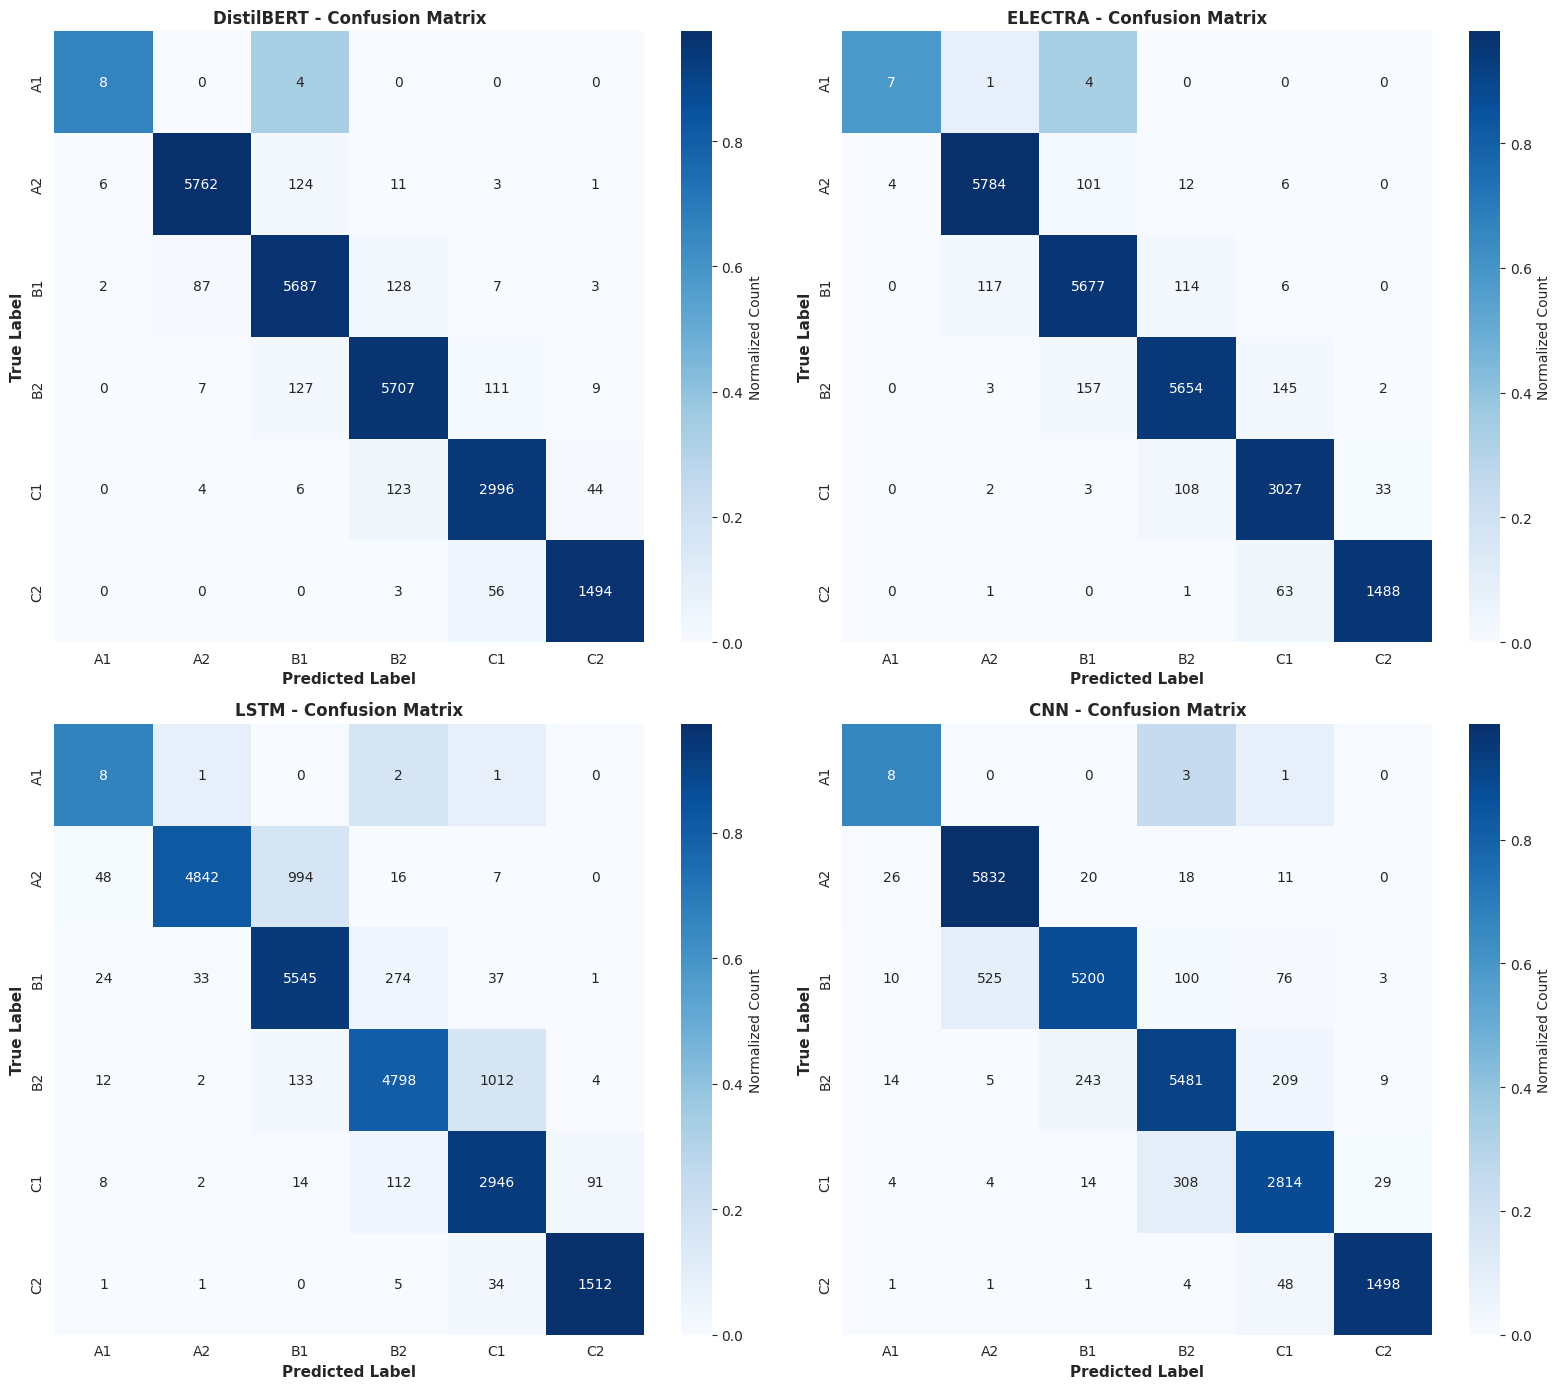


✅ Confusion matrices saved as 'confusion_matrices_comparison.png'


In [16]:
# Visualization 2: Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, (model_name, model_data) in enumerate(results.items()):
    cm = confusion_matrix(y_test, model_data['predictions'])
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(cm_normalized, annot=cm, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_,
                ax=axes[idx], cbar_kws={'label': 'Normalized Count'},
                annot_kws={'fontsize': 10})

    axes[idx].set_title(f'{model_name} - Confusion Matrix', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('True Label', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Predicted Label', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Confusion matrices saved as 'confusion_matrices_comparison.png'")

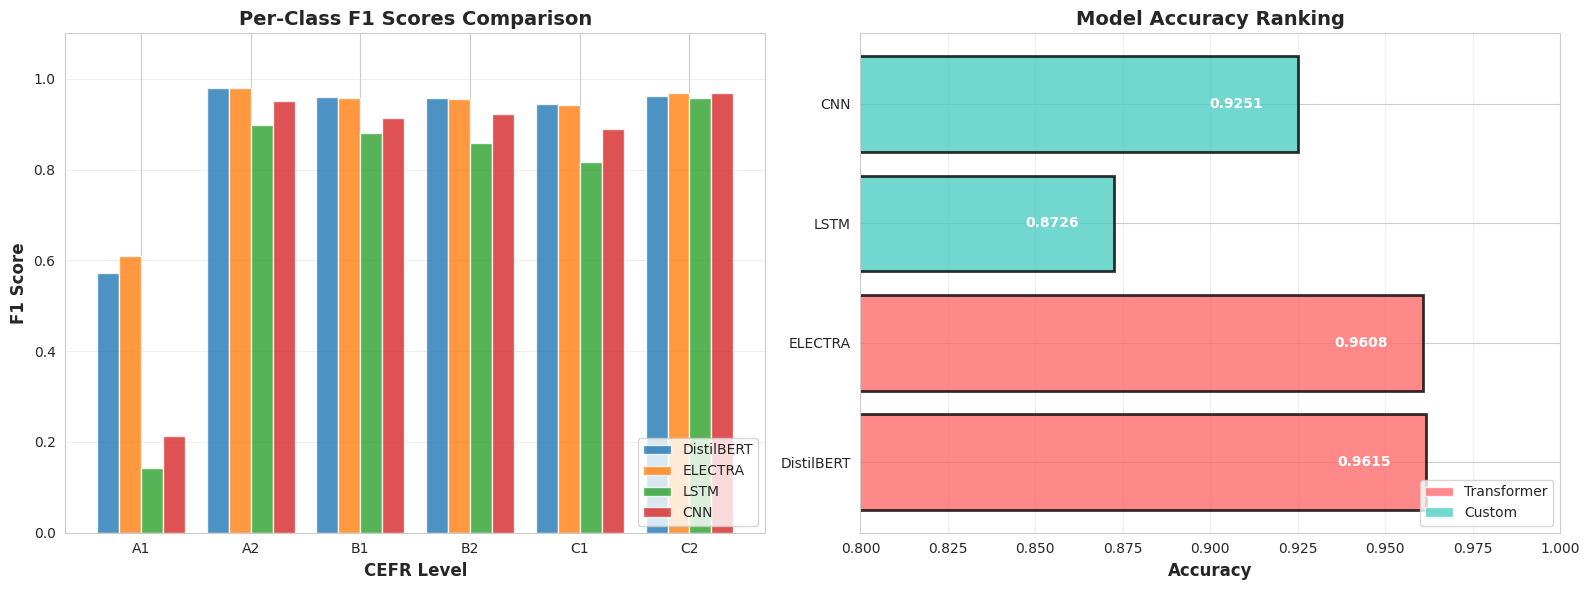


✅ Per-class comparison saved as 'per_class_comparison.png'


In [17]:
# Visualization 3: Per-Class Performance Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# F1 Scores per Class
ax = axes[0]
class_f1_scores = {}
for model_name, model_data in results.items():
    f1_scores = f1_score(y_test, model_data['predictions'], average=None)
    class_f1_scores[model_name] = f1_scores

x = np.arange(len(label_encoder.classes_))
width = 0.2
colors_list = ['#FF6B6B', '#4ECDC4', '#95E1D3', '#F38181']

for idx, (model_name, f1_scores) in enumerate(class_f1_scores.items()):
    offset = width * (idx - 1.5)
    ax.bar(x + offset, f1_scores, width, label=model_name, alpha=0.8)

ax.set_xlabel('CEFR Level', fontsize=12, fontweight='bold')
ax.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
ax.set_title('Per-Class F1 Scores Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(label_encoder.classes_)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.1])

# Accuracy Variance
ax = axes[1]
model_names = list(results.keys())
accuracies = [results[m]['accuracy'] for m in model_names]
model_types = [results[m]['type'] for m in model_names]

# Color by type
colors = ['#FF6B6B' if t == 'Transformer' else '#4ECDC4' for t in model_types]

bars = ax.barh(model_names, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
ax.set_xlabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Model Accuracy Ranking', fontsize=14, fontweight='bold')
ax.set_xlim([0.8, 1.0])
ax.grid(axis='x', alpha=0.3)

for i, (bar, acc) in enumerate(zip(bars, accuracies)):
    width = bar.get_width()
    ax.text(width - 0.01, bar.get_y() + bar.get_height()/2.,
            f'{acc:.4f}', ha='right', va='center', fontweight='bold', color='white')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#FF6B6B', alpha=0.8, label='Transformer'),
                   Patch(facecolor='#4ECDC4', alpha=0.8, label='Custom')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('per_class_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Per-class comparison saved as 'per_class_comparison.png'")

In [18]:
# Summary and Recommendations
print("\n" + "="*80)
print("COMPREHENSIVE SUMMARY & RECOMMENDATIONS")
print("="*80)

print("\n📊 MODEL RANKING (by Accuracy):")
print("-"*80)
sorted_results = sorted(results.items(), key=lambda x: x[1]['accuracy'], reverse=True)
for rank, (model_name, model_data) in enumerate(sorted_results, 1):
    print(f"{rank}. {model_name:20s} | Accuracy: {model_data['accuracy']:.4f} | " +
          f"F1 Weighted: {model_data['f1_weighted']:.4f} | Type: {model_data['type']}")

print("\n" + "="*80)
print("🔍 KEY INSIGHTS:")
print("="*80)

# Transformer vs Custom comparison
transformer_accs = [results[m]['accuracy'] for m in results if results[m]['type'] == 'Transformer']
custom_accs = [results[m]['accuracy'] for m in results if results[m]['type'] == 'Custom']

print(f"\n1. Transformer Models (DistilBERT, ELECTRA):")
print(f"   Average Accuracy: {np.mean(transformer_accs):.4f}")
print(f"   Max Accuracy: {np.max(transformer_accs):.4f}")
print(f"   Min Accuracy: {np.min(transformer_accs):.4f}")

print(f"\n2. Custom Models (LSTM, CNN):")
print(f"   Average Accuracy: {np.mean(custom_accs):.4f}")
print(f"   Max Accuracy: {np.max(custom_accs):.4f}")
print(f"   Min Accuracy: {np.min(custom_accs):.4f}")

accuracy_diff = np.mean(transformer_accs) - np.mean(custom_accs)
print(f"\n3. Performance Gap:")
print(f"   Transformers are {accuracy_diff:.4f} ({accuracy_diff*100:.2f}%) better on average")

print("\n" + "="*80)
print("✅ RECOMMENDATIONS:")
print("="*80)

best_model_name = sorted_results[0][0]
best_model_data = sorted_results[0][1]

print(f"\n🏆 Recommended Model: {best_model_name}")
print(f"   - Accuracy: {best_model_data['accuracy']:.4f}")
print(f"   - F1 Weighted: {best_model_data['f1_weighted']:.4f}")
print(f"   - Type: {best_model_data['type']}")

if best_model_data['type'] == 'Transformer':
    print(f"\n   ✓ Advantages:")
    print(f"     - Better understanding of context")
    print(f"     - Pre-trained on large corpus")
    print(f"     - Excellent generalization")
    print(f"\n   ✗ Disadvantages:")
    print(f"     - Slower inference")
    print(f"     - Requires more GPU memory")
    print(f"     - Larger model size")
else:
    print(f"\n   ✓ Advantages:")
    print(f"     - Faster inference")
    print(f"     - Lower memory requirements")
    print(f"     - Lightweight deployment")
    print(f"\n   ✗ Disadvantages:")
    print(f"     - Lower accuracy")
    print(f"     - Limited context understanding")

print("\n" + "="*80)
print("📈 CONCLUSION:")
print("="*80)
print(f"\nThe best performing model is {best_model_name} with {best_model_data['accuracy']:.4f} accuracy.")
print(f"This model is recommended for production deployment.")
print("="*80)


COMPREHENSIVE SUMMARY & RECOMMENDATIONS

📊 MODEL RANKING (by Accuracy):
--------------------------------------------------------------------------------
1. DistilBERT           | Accuracy: 0.9615 | F1 Weighted: 0.9616 | Type: Transformer
2. ELECTRA              | Accuracy: 0.9608 | F1 Weighted: 0.9608 | Type: Transformer
3. CNN                  | Accuracy: 0.9251 | F1 Weighted: 0.9255 | Type: Custom
4. LSTM                 | Accuracy: 0.8726 | F1 Weighted: 0.8752 | Type: Custom

🔍 KEY INSIGHTS:

1. Transformer Models (DistilBERT, ELECTRA):
   Average Accuracy: 0.9612
   Max Accuracy: 0.9615
   Min Accuracy: 0.9608

2. Custom Models (LSTM, CNN):
   Average Accuracy: 0.8988
   Max Accuracy: 0.9251
   Min Accuracy: 0.8726

3. Performance Gap:
   Transformers are 0.0623 (6.23%) better on average

✅ RECOMMENDATIONS:

🏆 Recommended Model: DistilBERT
   - Accuracy: 0.9615
   - F1 Weighted: 0.9616
   - Type: Transformer

   ✓ Advantages:
     - Better understanding of context
     - Pre-train

In [19]:
# Test on Custom Sentences
print("\n" + "="*80)
print("TESTING MODELS ON CUSTOM SENTENCES")
print("="*80)

test_sentences = [
    "I like cats",  # A1-A2
    "I have been studying English for three years",  # B1
    "The implementation of sustainable practices requires careful consideration",  # C1-C2
]

for sentence in test_sentences:
    print(f"\n{'='*80}")
    print(f"Sentence: \"{sentence}\"")
    print("-"*80)

    predictions = {}

    # DistilBERT
    if distilbert_model is not None:
        try:
            inputs = distilbert_tokenizer(sentence, return_tensors='pt', max_length=512,
                                         padding='max_length', truncation=True).to(device)
            with torch.no_grad():
                outputs = distilbert_model(**inputs)
                logits = outputs.logits
                probs = torch.softmax(logits, dim=1)[0]
                pred_idx = torch.argmax(probs).item()
                predictions['DistilBERT'] = (label_encoder.classes_[pred_idx], probs[pred_idx].item())
        except:
            pass

    # ELECTRA
    if electra_model is not None:
        try:
            inputs = electra_tokenizer(sentence, return_tensors='pt', max_length=512,
                                      padding='max_length', truncation=True).to(device)
            with torch.no_grad():
                outputs = electra_model(**inputs)
                logits = outputs.logits
                probs = torch.softmax(logits, dim=1)[0]
                pred_idx = torch.argmax(probs).item()
                predictions['ELECTRA'] = (label_encoder.classes_[pred_idx], probs[pred_idx].item())
        except:
            pass

    # LSTM
    if lstm_model is not None:
        try:
            input_ids = lstm_tokenizer.encode(sentence)
            input_tensor = torch.tensor([input_ids], dtype=torch.long).to(device)
            with torch.no_grad():
                logits = lstm_model(input_tensor)
                probs = torch.softmax(logits, dim=1)[0]
                pred_idx = torch.argmax(probs).item()
                predictions['LSTM'] = (label_encoder.classes_[pred_idx], probs[pred_idx].item())
        except:
            pass

    # CNN
    if cnn_model is not None:
        try:
            input_ids = cnn_tokenizer.encode(sentence)
            input_tensor = torch.tensor([input_ids], dtype=torch.long).to(device)
            with torch.no_grad():
                logits = cnn_model(input_tensor)
                probs = torch.softmax(logits, dim=1)[0]
                pred_idx = torch.argmax(probs).item()
                predictions['CNN'] = (label_encoder.classes_[pred_idx], probs[pred_idx].item())
        except:
            pass

    # Display predictions
    for model_name, (pred_label, confidence) in predictions.items():
        print(f"  {model_name:15s}: {pred_label} (confidence: {confidence:.4f})")

print("\n" + "="*80)


TESTING MODELS ON CUSTOM SENTENCES

Sentence: "I like cats"
--------------------------------------------------------------------------------
  DistilBERT     : A2 (confidence: 0.7177)
  ELECTRA        : A2 (confidence: 0.8766)
  LSTM           : A1 (confidence: 0.9996)
  CNN            : A2 (confidence: 1.0000)

Sentence: "I have been studying English for three years"
--------------------------------------------------------------------------------
  DistilBERT     : A2 (confidence: 0.7671)
  ELECTRA        : A2 (confidence: 0.7544)
  LSTM           : A2 (confidence: 0.8993)
  CNN            : A2 (confidence: 0.9997)

Sentence: "The implementation of sustainable practices requires careful consideration"
--------------------------------------------------------------------------------
  DistilBERT     : B2 (confidence: 0.7774)
  ELECTRA        : A2 (confidence: 0.3827)
  LSTM           : A2 (confidence: 0.9990)
  CNN            : A2 (confidence: 1.0000)



---
# 📊 COMPARISON COMPLETE!

## Overview
This notebook compares **4 CEFR classification models**:
1. **DistilBERT** - Transformer fine-tuning (distilbert_cefr_classifier)
2. **ELECTRA** - Transformer fine-tuning (electra_cefr_classifier)
3. **LSTM with Attention** - Custom architecture (LSTM_attention_cefr_classifier)
4. **CNN with Global Pooling** - Custom architecture (CNN_cefr_classifier)

## Results Generated
- ✅ Comprehensive comparison table with accuracy and F1 scores
- ✅ Visualization: Metric comparison bar charts
- ✅ Visualization: Confusion matrices for all models
- ✅ Visualization: Per-class F1 score comparison
- ✅ Detailed classification reports
- ✅ Model recommendations
- ✅ Custom sentence predictions

## Key Metrics
- **Accuracy**: Overall correctness
- **F1 Macro**: Average F1 across all classes (unweighted)
- **F1 Weighted**: Average F1 across all classes (weighted by support)

## Files Saved
- `model_comparison_metrics.png` - Accuracy, F1 scores, and model type distribution
- `confusion_matrices_comparison.png` - Normalized confusion matrices for all 4 models
- `per_class_comparison.png` - Per-class F1 scores and accuracy ranking

---